# EdgeEngine AWARE — one simulator, three application domains

EdgeEngine AWARE simulates an *energy-harvesting embedded node* that must decide how well to
sense and whether to transmit under a small, uncertain energy budget. The smart-agriculture
node is one instance of that problem. This notebook shows two more and, more importantly,
shows that they are the **same problem for the policy**: whatever the domain, the node sees
the same 18-number observation and returns the same (sensing level, radio mode) action.

| domain | monitored quantity (danger side) | energy source | radio | what drives the week |
|---|---|---|---|---|
| **agriculture** | soil moisture (low) | solar cell | LoRa-like, 3 spreading factors | weather: sun, clouds, rain, irrigation |
| **indoor_air** | CO₂ of a classroom (high) | indoor PV under the ceiling lights (+ window) | BLE-like, 3 PHY modes | occupancy: lights and people come and go together; nights and weekends bring neither |
| **industrial** | bearing temperature of a motor (high) | thermoelectric generator on the warm casing | LoRa-like | shifts: the machine's heat is both the energy source and the monitored variable; faults make it run hotter until maintenance |

What this notebook does:

1. puts the three domains side by side — energy budgets, time patterns, what "critical" means;
2. replays one week in each with the rule-based controller;
3. runs the baseline protocol (rule-based and periodic duty cycles) on every scenario of every domain;
4. asks the cross-domain question: does a policy trained in one domain work in another? First with the
   agriculture-trained PPO shipped in the repository, then — when the runs of
   `examples/run_cross_domain.sh` are present — with one policy per domain and a "universal" one
   trained on all of them.

## 0. Setup

In [1]:
%matplotlib inline
import json, time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import edgeengine_aware as ea
from edgeengine_aware import EdgeEngineAwareEnv, NodeProfile, PeriodicPolicy, RuleBasedParams, RuleBasedPolicy, run_episode
from edgeengine_aware.domains import DOMAINS, DOMAIN_NAMES, domain_config
from edgeengine_aware.scenarios import scenario_names, split_scenario_name, get_scenario
from edgeengine_aware.rl import NumpyMLPPolicy, evaluate, make_env
from edgeengine_aware.deployment import PolicyBundle

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#e34948"]
DOMAIN_COLOR = dict(zip(DOMAIN_NAMES, PALETTE[:3]))
ROOT = Path(ea.__file__).resolve().parents[1]
RUNS = ROOT / "examples" / "rl_runs"
DAY = 86400.0
EVAL_SEEDS = range(1000, 1010)
print("EdgeEngine AWARE", ea.__version__, "— domains:", DOMAIN_NAMES)

EdgeEngine AWARE 0.4.0 — domains: ('agriculture', 'indoor_air', 'industrial')


## 1. The three domains at a glance

Each domain is a configuration of the same environment (`edgeengine_aware.domains`): a hidden
*process* (what the sensor samples), an *energy source*, a hardware profile (energy per
operation, radio table) and a set of benchmark scenarios. The table below is computed by
running the rule-based controller for a week in each domain: how much energy the node can
harvest per day, what it needs just to stay alive, and what an hourly accurate report would
cost — the three numbers that decide whether energy is the binding constraint.

In [2]:
rows = []
for name in DOMAIN_NAMES:
    cfg = domain_config(name)
    prof = NodeProfile.from_config(cfg)
    env = EdgeEngineAwareEnv(cfg)
    harv, zone_w, zone_c = [], [], []
    for s in range(3):
        run_episode(env, RuleBasedPolicy(profile=prof), seed=s)
        m = env.metrics
        harv.append(m.total_harvested_energy_j / cfg.time.episode_days)
        z = np.array([cfg.quantity.zone(v) for v in env.log.true_moisture])
        zone_w.append((z == 1).mean()); zone_c.append((z == 2).mean())
    q = cfg.quantity
    rows.append({
        "domain": name,
        "quantity": f"{q.name} [{q.unit}]",
        "danger": "high" if q.critical_is_upper else "low",
        "thresholds": f"{q.to_physical(q.warning_threshold):g} / {q.to_physical(q.critical_threshold):g}",
        "storage [J]": cfg.storage.capacity_j,
        "always-on [µW]": cfg.mcu.baseline_power_w * 1e6,
        "harvest [J/day]": np.mean(harv),
        "baseline [J/day]": cfg.mcu.baseline_power_w * DAY,
        "hourly report [J/day]": 24 * (cfg.sensing.energy_j[2] + cfg.communication.tx_energy_j),
        "radio uplink [J]": cfg.communication.tx_energy_j,
        "time in warning": np.mean(zone_w),
        "time in critical": np.mean(zone_c),
    })
    env.close()
glance = pd.DataFrame(rows).set_index("domain")
glance.round(3)

,quantity,danger,thresholds,storage [J],always-on [µW],harvest [J/day],baseline [J/day],hourly report [J/day],radio uplink [J],time in warning,time in critical
domain,,,,,,,,,,,
agriculture,soil moisture [fraction of field capacity],low,0.35 / 0.25,300.0,200.0,64.010,17.280,28.800,0.600,0.253,0.127
indoor_air,CO2 concentration [ppm],high,1000 / 1500,60.0,20.0,4.186,1.728,3.629,0.001,0.198,0.034
industrial,bearing temperature [degC],high,70 / 90,120.0,200.0,72.996,17.280,26.400,0.600,0.240,0.011


Reading the table: in **agriculture** the harvest comfortably exceeds an hourly report on an
average week — energy binds only on cloudy weeks and small batteries (the stress scenarios).
In **indoor_air** the node lives on tens of microwatts: the CO₂ sensor is the energy hog and
an hourly accurate report around the clock would exceed what the lights provide, so *when* to
sense matters more than *how* to transmit (BLE uplinks are almost free). In **industrial**
the machine's heat yields hundreds of joules on a working day, far more than the node can use
or store, and nothing over the weekend: the storage is sized so that a weekend of hourly
reports is just about affordable.

## 2. One week in each domain

The rule-based controller, the same code in all three domains (it only reads the normalised
observation), over a week starting on a Monday. Top: harvested power and battery. Middle: the
monitored quantity in physical units with the warning / critical thresholds, and — for the
scheduled domains — the hidden activity level (people in the room, machine load). Bottom:
transmissions by radio mode and the application's priority.

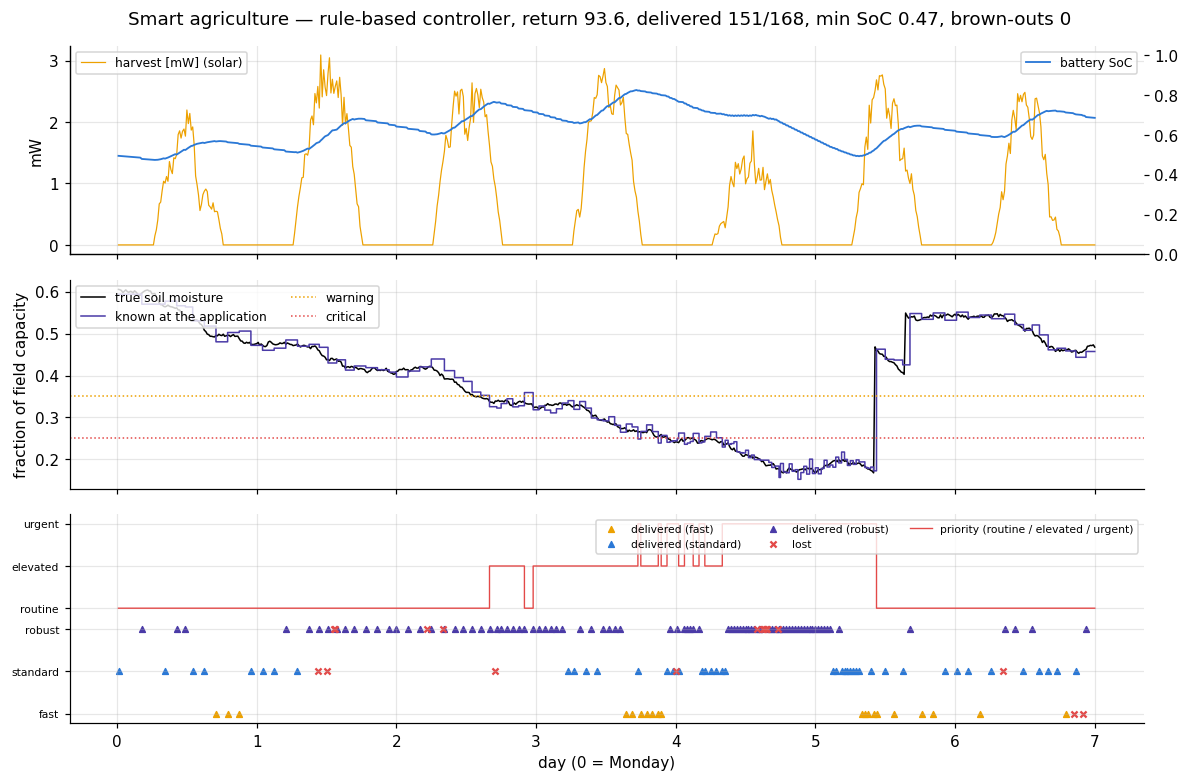

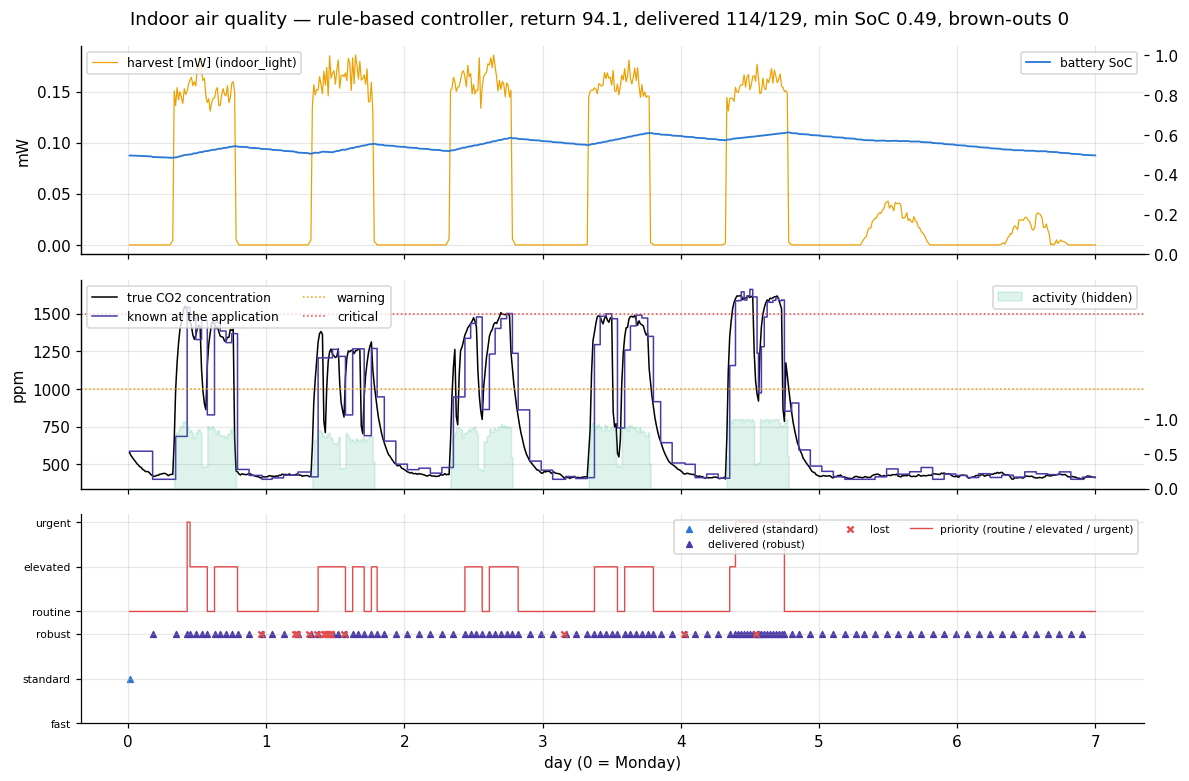

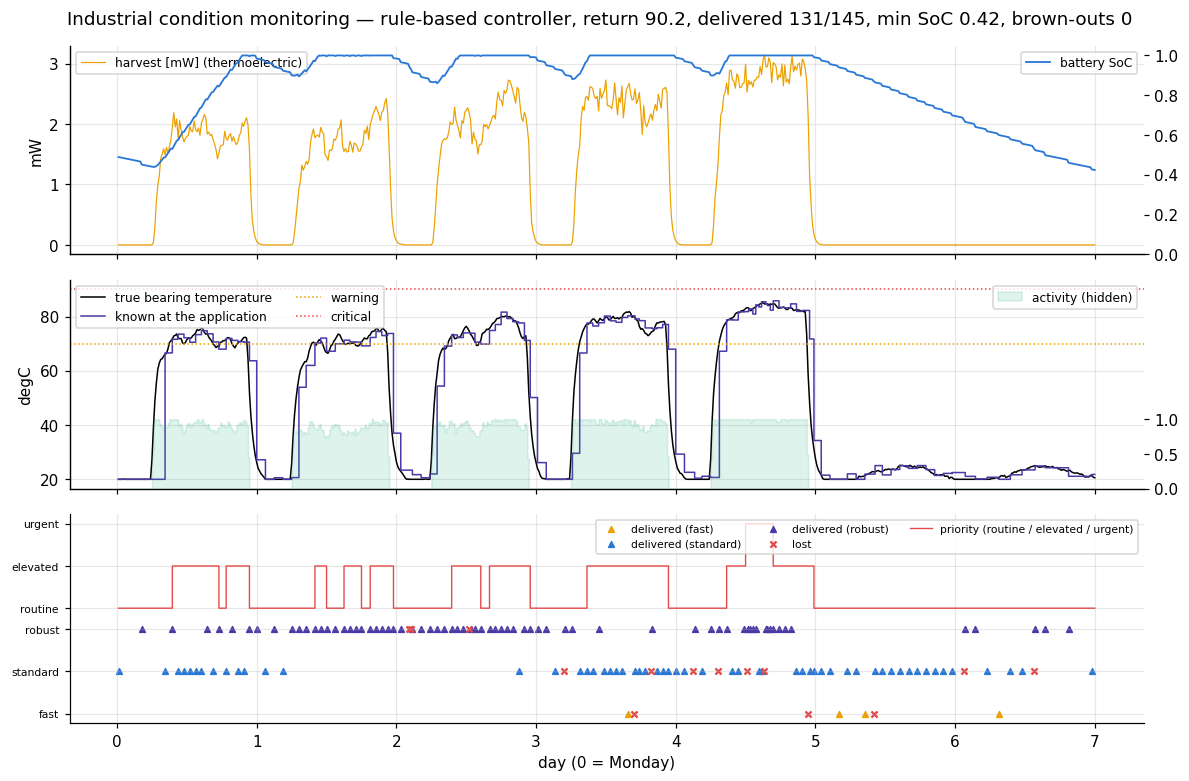

In [3]:
MODE_COLORS = ["#eda100", "#2a78d6", "#4a3aa7"]

def plot_week(name, seed=2):
    cfg = domain_config(name); q = cfg.quantity
    prof = NodeProfile.from_config(cfg)
    env = EdgeEngineAwareEnv(cfg)
    res = run_episode(env, RuleBasedPolicy(profile=prof), seed=seed)
    log, m = env.log, env.metrics
    t = np.asarray(log.time_s) / DAY
    fig, axes = plt.subplots(3, 1, figsize=(11, 7.2), sharex=True)
    ax = axes[0]
    ax.plot(t, np.asarray(log.harvest_power_w) * 1e3, color=PALETTE[3], lw=0.8, label=f"harvest [mW] ({cfg.harvesting_source})")
    ax.set_ylabel("mW"); ax.legend(loc="upper left", fontsize=8)
    ax2 = ax.twinx(); ax2.plot(t, log.soc, color=PALETTE[0], lw=1.2, label="battery SoC"); ax2.set_ylim(0, 1.05); ax2.grid(False); ax2.legend(loc="upper right", fontsize=8)
    ax = axes[1]
    phys = np.array([q.to_physical(v) for v in log.true_moisture])
    ax.plot(t, phys, color="k", lw=1, label=f"true {q.name}")
    ax.plot(t, [q.to_physical(v) if not np.isnan(v) else np.nan for v in log.app_moisture], color=PALETTE[5], lw=1, drawstyle="steps-post", label="known at the application")
    ax.axhline(q.to_physical(q.warning_threshold), color=PALETTE[3], ls=":", lw=1, label="warning")
    ax.axhline(q.to_physical(q.critical_threshold), color=PALETTE[6], ls=":", lw=1, label="critical")
    ax.set_ylabel(q.unit); ax.legend(fontsize=8, loc="upper left", ncol=2)
    if env.schedule is not None:
        ax3 = ax.twinx(); ax3.fill_between(t, 0, log.humidity, color=PALETTE[2], alpha=0.15, step="post", label="activity (hidden)"); ax3.set_ylim(0, 3); ax3.set_yticks([0, 0.5, 1]); ax3.grid(False); ax3.legend(loc="upper right", fontsize=8)
    ax = axes[2]
    att, suc, mode = np.asarray(log.tx_attempt), np.asarray(log.tx_success), np.asarray(log.tx_mode)
    for k, nm in enumerate(("fast", "standard", "robust")):
        sel = (att == 1) & (suc == 1) & (mode == k)
        if sel.any(): ax.scatter(t[sel], np.full(sel.sum(), k), marker="^", s=14, color=MODE_COLORS[k], label=f"delivered ({nm})")
    fail = (att == 1) & (suc == 0)
    if fail.any(): ax.scatter(t[fail], mode[fail], marker="x", s=16, color=PALETTE[6], label="lost")
    ax.step(t, np.asarray(log.priority) - 0.5 + 3, where="post", color=PALETTE[6], lw=0.9, label="priority (routine / elevated / urgent)")
    ax.set_yticks([0, 1, 2, 2.5, 3.5, 4.5]); ax.set_yticklabels(["fast", "standard", "robust", "routine", "elevated", "urgent"], fontsize=7)
    ax.legend(fontsize=7, ncol=3, loc="upper right"); ax.set_xlabel("day (0 = Monday)")
    fig.suptitle(f"{DOMAINS[name].title} — rule-based controller, return {res.total_reward:.1f}, delivered {m.n_successful_transmissions}/{m.n_transmissions}, min SoC {m.min_battery_soc:.2f}, brown-outs {m.battery_depletion_events}")
    fig.tight_layout(); plt.show(); env.close()

for name in DOMAIN_NAMES:
    plot_week(name)

## 3. Baselines on every scenario of every domain

The protocol of the RL notebook applied to all 16 scenarios: deterministic policies, 7-day
episodes, 10 held-out seeds. The rule-based controller and the two periodic duty cycles
(accurate reading + standard uplink every hour or every three hours) are the same objects in
every domain.

In [4]:
ALL = scenario_names("all")
def rule_for(scen):
    prof = NodeProfile.from_config(get_scenario(scen))
    return lambda: RuleBasedPolicy(RuleBasedParams(), prof)

t0 = time.time()
rows = []
for scen in ALL:
    pols = {"rule-based": rule_for(scen), "periodic 1h": lambda: PeriodicPolicy(4, 2, 2), "periodic 3h": lambda: PeriodicPolicy(12, 2, 2)}
    rows += evaluate(pols, [scen], seeds=EVAL_SEEDS)
print(f"{len(rows)} episodes in {time.time() - t0:.0f} s")
base = pd.DataFrame([r.as_dict() for r in rows])
base["domain"] = [split_scenario_name(s)[0] for s in base.scenario]
summary = base.pivot_table(index=["domain", "scenario"], columns="policy", values=["reward", "min_soc", "depletions"], aggfunc="mean")
summary.round(2)

480 episodes in 70 s


depletions                         \
policy                                  periodic 1h periodic 3h rule-based   
domain      scenario                                                         
agriculture cloudy_week                        10.8         0.0        0.0   
            default                             0.0         0.0        0.0   
            demanding_application               0.0         0.0        0.0   
            drought                             0.0         0.0        0.0   
            lossy_link                          0.0         0.0        0.0   
            tiny_battery                        0.0         0.0        0.0   
indoor_air  indoor_air:default                  0.0         0.0        0.0   
            indoor_air:dim_lights               0.0         0.0        0.0   
            indoor_air:long_hours               0.0         0.0        0.0   
            indoor_air:no_window                0.0         0.0        0.0   
            indoor_air:weak_ventilation         0.0         0.0        0.0   
industrial  industrial:continuous               0.0         0.0        0.0   
            industrial:default                  0.0         0.0        0.0   
            industrial:degrading                0.0         0.0        0.0   
            industrial:single_shift             6.4         0.0        0.0   
            industrial:weak_link                0.0         0.0        0.0   

                                            min_soc                         \
policy                                  periodic 1h periodic 3h rule-based   
domain      scenario                                                         
agriculture cloudy_week                        0.09        0.32       0.24   
            default                            0.44        0.47       0.46   
            demanding_application              0.44        0.47       0.44   
            drought                            0.44        0.47       0.39   
            lossy_link                         0.44        0.47       0.42   
            tiny_battery                       0.38        0.45       0.42   
indoor_air  indoor_air:default                 0.42        0.48       0.48   
            indoor_air:dim_lights              0.09        0.37       0.36   
            indoor_air:long_hours              0.47        0.48       0.48   
            indoor_air:no_window               0.33        0.48       0.45   
            indoor_air:weak_ventilation        0.42        0.48       0.46   
industrial  industrial:continuous              0.50        0.50       0.50   
            industrial:default                 0.28        0.44       0.38   
            industrial:degrading               0.28        0.44       0.39   
            industrial:single_shift            0.12        0.42       0.31   
            industrial:weak_link               0.28        0.44       0.27   

                                             reward                         
policy                                  periodic 1h periodic 3h rule-based  
domain      scenario                                                        
agriculture cloudy_week                      -26.73       64.76      60.73  
            default                           68.37       64.15      75.28  
            demanding_application             64.71       57.91      71.47  
            drought                          115.68       96.84     123.94  
            lossy_link                        40.42       16.97      67.97  
            tiny_battery                      67.60       62.65      74.94  
indoor_air  indoor_air:default                86.46       44.96      94.52  
            indoor_air:dim_lights             63.39       44.96      60.73  
            indoor_air:long_hours            108.71       52.19     125.47  
            indoor_air:no_window              86.46       44.96      93.66  
            indoor_air:weak_ventilation      107.47       51.04     133.26

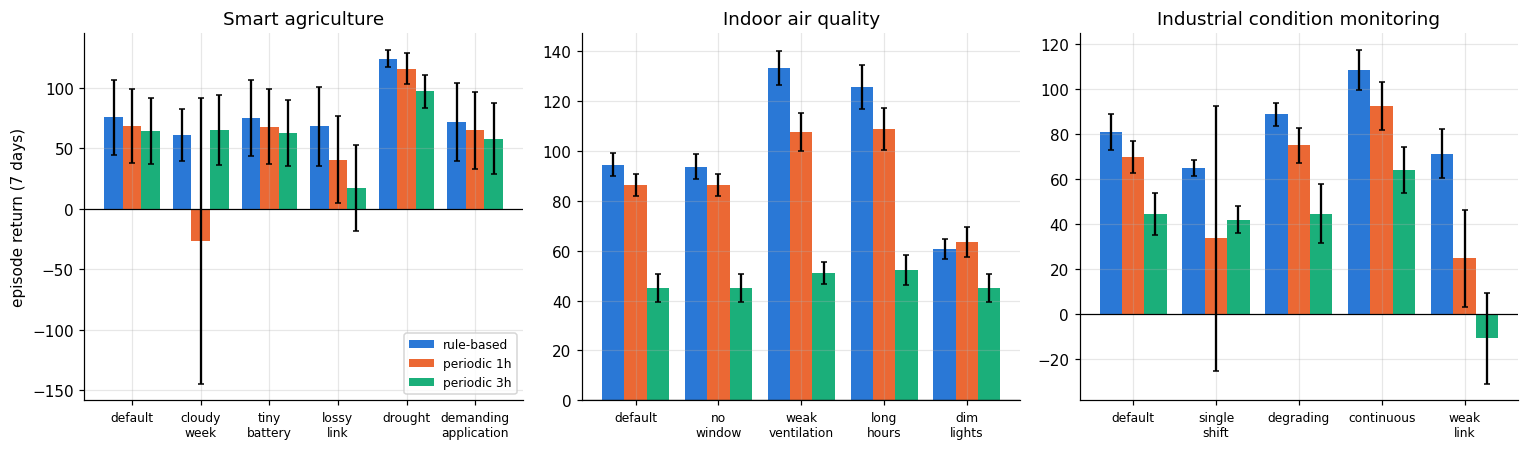

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for ax, name in zip(axes, DOMAIN_NAMES):
    scens = [s for s in ALL if split_scenario_name(s)[0] == name]
    x = np.arange(len(scens)); w = 0.27
    for j, pol in enumerate(["rule-based", "periodic 1h", "periodic 3h"]):
        sub = base[(base.policy == pol) & (base.scenario.isin(scens))].groupby("scenario")["reward"].agg(["mean", "std"]).reindex(scens)
        ax.bar(x + (j - 1) * w, sub["mean"], width=w, yerr=sub["std"], capsize=2, color=PALETTE[j], label=pol)
    ax.set_xticks(x); ax.set_xticklabels([split_scenario_name(s)[1].replace("_", "\n") for s in scens], fontsize=8)
    ax.set_title(DOMAINS[name].title); ax.axhline(0, color="k", lw=0.8)
axes[0].set_ylabel("episode return (7 days)"); axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 4. Does a policy transfer across domains?

This is the question the shared contract makes askable. A policy never sees soil moisture or
ppm: it sees a normalised value, its importance (distance to the thresholds, whichever side the
danger is on), its energy costs relative to the storage, the harvest relative to a reference
power, ages and priorities. If it learned *energy–information trade-offs* it should work
anywhere; if it learned *the solar day*, it should not.

### 4a. The agriculture-trained PPO on the other domains (no training needed)

`examples/bundles/ppo_long.json` is the 5 M-step PPO trained on the agricultural scenarios
(section 10 of `train_rl.ipynb`). Here it runs with the numpy runtime on every scenario of the
three domains, against the rule-based controller.

In [6]:
bundle = PolicyBundle.load(ROOT / "examples" / "bundles" / "ppo_long.json")
ppo_agri = lambda: NumpyMLPPolicy(bundle.model)
rows = []
for scen in ALL:
    rows += evaluate({"PPO (agriculture, 5M)": ppo_agri, "rule-based": rule_for(scen)}, [scen], seeds=EVAL_SEEDS)
xfer = pd.DataFrame([r.as_dict() for r in rows])
xfer["domain"] = [split_scenario_name(s)[0] for s in xfer.scenario]
piv = xfer.pivot_table(index="scenario", columns="policy", values="reward", aggfunc="mean").reindex(ALL)
piv["advantage"] = piv["PPO (agriculture, 5M)"] - piv["rule-based"]
soc = xfer.pivot_table(index="scenario", columns="policy", values="min_soc", aggfunc="mean").reindex(ALL)
dep = xfer.pivot_table(index="scenario", columns="policy", values="depletions", aggfunc="mean").reindex(ALL)
out = piv.copy(); out["PPO min SoC"] = soc["PPO (agriculture, 5M)"]; out["PPO brown-outs"] = dep["PPO (agriculture, 5M)"]
out.round(2)

policy,"PPO (agriculture, 5M)",rule-based,advantage,PPO min SoC,PPO brown-outs
scenario,,,,,
default,73.05,75.28,-2.23,0.47,0.0
cloudy_week,69.43,60.73,8.70,0.29,0.0
tiny_battery,72.07,74.94,-2.87,0.44,0.0
lossy_link,65.10,67.97,-2.86,0.45,0.0
drought,123.73,123.94,-0.21,0.46,0.0
demanding_application,70.28,71.47,-1.19,0.47,0.0
indoor_air:default,63.60,94.52,-30.92,0.46,0.0
indoor_air:no_window,63.99,93.66,-29.67,0.38,0.0
indoor_air:weak_ventilation,73.97,133.26,-59.28,0.46,0.0


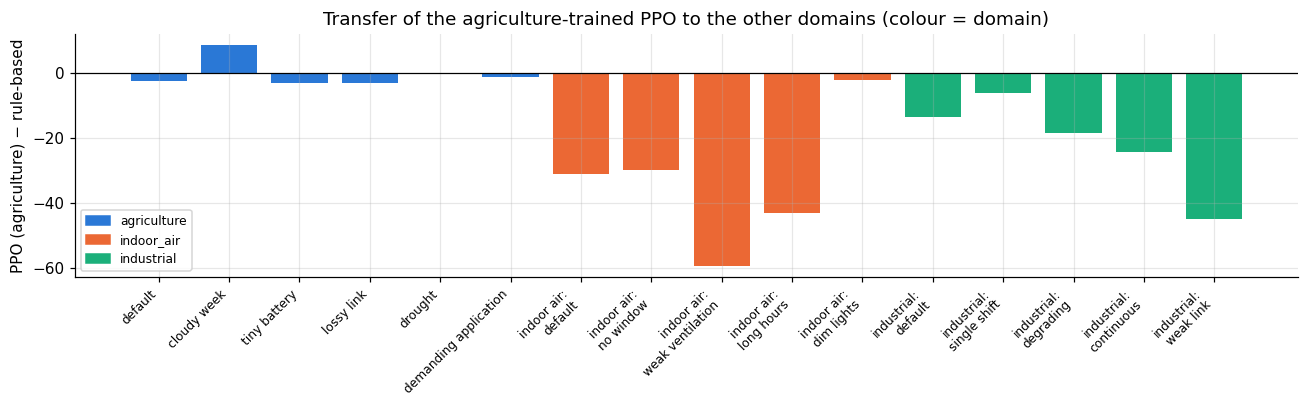

policy,"PPO (agriculture, 5M)",rule-based,advantage
domain,,,
agriculture,78.9,79.1,-0.1
indoor_air,68.5,101.5,-33.0
industrial,61.6,82.9,-21.4


In [7]:
fig, ax = plt.subplots(figsize=(12, 3.8))
adv = piv["advantage"]
colors = [DOMAIN_COLOR[split_scenario_name(s)[0]] for s in ALL]
ax.bar(range(len(ALL)), adv.values, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(ALL))); ax.set_xticklabels([s.replace(":", ":\n").replace("_", " ") for s in ALL], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("PPO (agriculture) − rule-based")
ax.set_title("Transfer of the agriculture-trained PPO to the other domains (colour = domain)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=DOMAIN_COLOR[n], label=n) for n in DOMAIN_NAMES], fontsize=8)
fig.tight_layout(); plt.show()
by_dom = xfer.groupby(["domain", "policy"])["reward"].mean().unstack()
by_dom["advantage"] = by_dom["PPO (agriculture, 5M)"] - by_dom["rule-based"]
by_dom.round(1)

### 4b. One policy per domain and a universal one

`examples/run_cross_domain.sh` trains PPO (5 M steps, two seeds) on the scenario mixture of
each domain and on the mixture of all of them, and evaluates every policy on the scenarios of
every domain. The cells below read those runs from `examples/rl_runs/seeds_domains/` and build
the **train-domain × test-domain matrix**: each cell is the mean, over the test domain's
scenarios and the training seeds, of the return minus the rule-based controller's return on
the same scenario. The diagonal is in-domain performance; off-diagonal cells are transfer.

{'agriculture': '2 runs', 'all': '2 runs', 'indoor_air': '2 runs', 'industrial': '2 runs'} — 5000000 steps each


test,agriculture,indoor_air,industrial
train,,,
agriculture,4.2,-23.8,-13.7
indoor_air,-668.2,51.0,-525.6
industrial,-9.0,13.4,-2.5
all,-6.1,45.6,-10.5


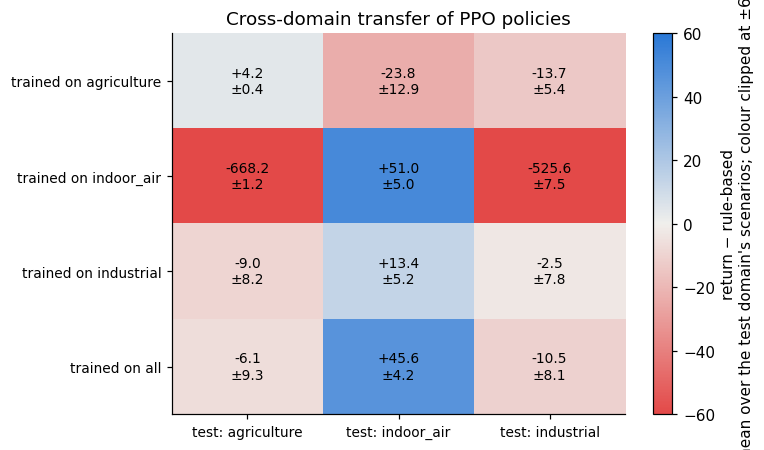

train,agriculture,all,indoor_air,industrial
scenario,,,,
default,3.6,-6.7,-584.4,-9.5
cloudy_week,11.1,-10.7,-808.5,-10.8
tiny_battery,2.7,-7.4,-825.2,-9.7
lossy_link,3.2,-2.9,-576.2,-5.9
drought,-0.4,-5.1,-631.5,-11.0
demanding_application,4.9,-4.0,-583.5,-7.2
indoor_air:default,-21.3,40.1,42.9,17.1
indoor_air:no_window,-22.2,35.4,36.8,10.3
indoor_air:weak_ventilation,-47.0,62.4,69.7,11.1


In [8]:
DOM_DIR = RUNS / "seeds_domains"
runs = []
if DOM_DIR.exists():
    for f in sorted(DOM_DIR.glob("ppo_*_seed*.json")):
        if "bundle" in f.name:
            continue
        d = json.loads(f.read_text()); runs.append(d)
if not runs:
    print("no cross-domain runs found — run  bash examples/run_cross_domain.sh  on a machine with the RL extras and re-execute this section")
else:
    rb = base[base.policy == "rule-based"].groupby("scenario")["reward"].mean()
    recs = []
    for d in runs:
        per_scen = pd.DataFrame(d["rows"]).groupby("scenario")["reward"].mean()
        for scen, val in per_scen.items():
            recs.append({"train": d["domain"], "seed": d["seed"], "steps": d["steps"], "scenario": scen, "test": split_scenario_name(scen)[0], "reward": val, "advantage": val - rb.get(scen, np.nan)})
    X = pd.DataFrame(recs)
    print({k: f"{v} runs" for k, v in X.groupby('train')['seed'].nunique().items()}, "—", X.steps.iloc[0], "steps each")
    order_tr = [d for d in ["agriculture", "indoor_air", "industrial", "all"] if d in set(X.train)]
    M = X.groupby(["train", "test"])["advantage"].mean().unstack().reindex(index=order_tr, columns=list(DOMAIN_NAMES))
    S = X.groupby(["train", "test", "seed"])["advantage"].mean().groupby(["train", "test"]).std().unstack().reindex(index=order_tr, columns=list(DOMAIN_NAMES))
    display(M.round(1))
    from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
    cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
    lim = 60.0  # colour scale clipped at ±60 so the informative cells stay readable; the numbers are exact
    fig, ax = plt.subplots(figsize=(7, 4.2))
    im = ax.imshow(np.clip(M.values, -lim, lim), cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels([f"test: {c}" for c in M.columns], fontsize=9)
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels([f"trained on {r}" for r in M.index], fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M.values[i, j]:+.1f}\n±{S.values[i, j]:.1f}", ha="center", va="center", fontsize=9)
    ax.grid(False); plt.colorbar(im, ax=ax, label="return − rule-based\n(mean over the test domain's scenarios; colour clipped at ±60)")
    ax.set_title("Cross-domain transfer of PPO policies"); fig.tight_layout(); plt.show()
    display(X.pivot_table(index="scenario", columns="train", values="advantage", aggfunc="mean").reindex(ALL).round(1))

### 4c. Is the indoor win real, or is the rule-based controller just mis-tuned?

The rule-based thresholds (report every 2 h / 1 h / 30 min, a check every hour, economy below
50 % SoC) were chosen for the agricultural node. In the indoor domain the CO₂ changes within
half an hour and BLE uplinks are almost free, so a fair comparison also needs a rule re-tuned
for that domain. The cell below evaluates two re-tuned variants next to the indoor-trained PPO.

In [9]:
indoor_scen = [s for s in ALL if s.startswith("indoor_air:")]
variants = {
    "rule-based (agriculture tuning)": RuleBasedParams(),
    "rule-based, fast (30/15/15 min, check 15 min)": RuleBasedParams(report_interval_h=(0.5, 0.25, 0.25), check_interval_h=0.25),
    "rule-based, fast + late economy (SoC < 20 %)": RuleBasedParams(report_interval_h=(0.5, 0.25, 0.25), check_interval_h=0.25, soc_low=0.2, soc_critical=0.1),
}
pols_by_scen = {}
tuned_rows = []
for scen in indoor_scen:
    prof = NodeProfile.from_config(get_scenario(scen))
    pols = {k: (lambda p=p, prof=prof: RuleBasedPolicy(p, prof)) for k, p in variants.items()}
    b_in = ROOT / "examples" / "bundles" / "ppo_indoor_air.json"
    if b_in.exists():
        m_in = PolicyBundle.load(b_in).model
        pols["PPO trained on indoor_air (5M)"] = lambda m=m_in: NumpyMLPPolicy(m)
    tuned_rows += evaluate(pols, [scen], seeds=EVAL_SEEDS)
T = pd.DataFrame([r.as_dict() for r in tuned_rows])
tab = T.pivot_table(index="policy", columns="scenario", values="reward", aggfunc="mean")[indoor_scen]
tab["mean"] = tab.mean(axis=1)
tab["min SoC"] = T.groupby("policy")["min_soc"].mean()
tab["uplinks / week"] = T.groupby("policy")["n_tx"].mean()
tab["readings / week"] = T.groupby("policy")["n_sensing"].mean()
tab.round(1)

scenario,indoor_air:default,indoor_air:no_window,indoor_air:weak_ventilation,indoor_air:long_hours,indoor_air:dim_lights,mean,min SoC,uplinks / week,readings / week
policy,,,,,,,,,
PPO trained on indoor_air (5M),138.5,130.1,205.1,185.5,113.2,154.5,0.2,488.6,360.4
rule-based (agriculture tuning),94.5,93.7,133.3,125.5,60.7,101.5,0.4,121.4,157.2
"rule-based, fast (30/15/15 min, check 15 min)",117.3,112.5,160.6,156.5,57.5,120.9,0.2,238.3,231.0
"rule-based, fast + late economy (SoC < 20 %)",66.4,22.9,81.2,127.0,-34.3,52.6,0.1,291.9,348.5


## 5. Findings

In [10]:
lines = []
for name in DOMAIN_NAMES:
    g = glance.loc[name]
    lines.append(f"* {name}: harvest {g['harvest [J/day]']:.1f} J/day vs always-on {g['baseline [J/day]']:.1f} J/day and {g['hourly report [J/day]']:.1f} J/day for hourly accurate reports; "
                 f"time in warning/critical {g['time in warning']:.0%}/{g['time in critical']:.0%}.")
for name in DOMAIN_NAMES:
    r = base[(base.domain == name)].groupby("policy")["reward"].mean()
    lines.append(f"* baselines in {name}: rule-based {r['rule-based']:.1f}, periodic 1h {r['periodic 1h']:.1f}, periodic 3h {r['periodic 3h']:.1f} (mean over the domain's scenarios).")
for name in DOMAIN_NAMES:
    lines.append(f"* agriculture-trained PPO on {name}: {by_dom.loc[name, 'advantage']:+.1f} vs rule-based (mean over scenarios).")
if runs:
    for tr in M.index:
        lines.append(f"* PPO trained on {tr}: " + ", ".join(f"{te} {M.loc[tr, te]:+.1f}" for te in M.columns) + " vs rule-based.")
    lines.append("* indoor_air, rule re-tuned for the domain: " + ", ".join(f"{p.split(',')[0] if 'PPO' in p else p}: {tab.loc[p, 'mean']:.1f}" for p in tab.index) + " (mean over the indoor scenarios).")
print("\n".join(lines))

* agriculture: harvest 64.0 J/day vs always-on 17.3 J/day and 28.8 J/day for hourly accurate reports; time in warning/critical 25%/13%.
* indoor_air: harvest 4.2 J/day vs always-on 1.7 J/day and 3.6 J/day for hourly accurate reports; time in warning/critical 20%/3%.
* industrial: harvest 73.0 J/day vs always-on 17.3 J/day and 26.4 J/day for hourly accurate reports; time in warning/critical 24%/1%.
* baselines in agriculture: rule-based 79.1, periodic 1h 55.0, periodic 3h 60.5 (mean over the domain's scenarios).
* baselines in indoor_air: rule-based 101.5, periodic 1h 90.5, periodic 3h 47.6 (mean over the domain's scenarios).
* baselines in industrial: rule-based 82.9, periodic 1h 59.1, periodic 3h 36.8 (mean over the domain's scenarios).
* agriculture-trained PPO on agriculture: -0.1 vs rule-based (mean over scenarios).
* agriculture-trained PPO on indoor_air: -33.0 vs rule-based (mean over scenarios).
* agriculture-trained PPO on industrial: -21.4 vs rule-based (mean over scenarios).


**What to take from this notebook**

* The abstraction holds: three physically different systems — a solar field node, a
  micro-power indoor CO₂ node, a heat-powered machine node — run through the same environment,
  the same observation, the same controller and the same firmware runtime. Only the hidden
  world, the hardware profile and the danger side of the thresholds change.
* The three domains stress different things. Agriculture is about weather and the slow drift
  towards a threshold; indoor air is about *when* to spend an expensive sensor reading when
  energy and relevance arrive together and vanish together; the industrial node is about
  weekends and faults — plenty of energy while the machine runs, none when it stops, and a drift
  towards the alarm that the node must catch.
* Cross-domain transfer is the honest test of what a learned policy encodes, and the matrix of
  section 4b answers it in three parts (5 M steps, two training seeds, advantage over the
  rule-based controller averaged over the test domain's scenarios):
  * **No transfer without training.** The agriculture policy loses 15–25 points in the other
    domains; the indoor policy is catastrophic elsewhere (−500 and worse): it learned that
    transmitting is free (BLE, 1 mJ) and drains a LoRa node's battery in a day. The energy costs
    *are* in the observation, but a policy that never saw them vary cannot read them.
  * **Trained in its domain, PPO is at parity with the rule-based controller on the two "physical"
    domains** (agriculture +2, industrial −4 ± 8) and **far ahead in the indoor domain (+50)**. The
    indoor node is where the rule's fixed report intervals are most wrong: relevance is bursty
    (people arrive, CO₂ climbs within half an hour, then nothing for 14 hours) and uplinks are
    almost free, so the learned policy reports every 15 minutes while the room is occupied and
    sleeps otherwise. A rule re-tuned for the domain (section 4c) recovers only part of the gap.
  * **The universal policy** (trained on the mixture of all three) keeps most of the indoor gain
    (+45) and stays within ~10 points of the rule on the other two — one network can serve three
    products with a modest loss on each, at two seeds and 5 M steps; more steps and seeds would
    tell how much of that loss is noise (the seed spread is 8–9 on those cells).
  * The `industrial:continuous` scenario (24/7 plant, energy-rich) is the one every learned policy
    loses (−19 to −29): with no weekend to save for, the rule's simple hourly reporting is close to
    optimal and PPO's caution costs it.